# Chapter 3 - Exercise 2

Write a function that can shift an MNIST image in any direction (left, right, up or down) by one pixel. Then for each image in the training set, create four shifted copies (one per direction) and add them to training set. Finally, train your best model on this expanded training set and measure its accuracy on the test set.

In [15]:
from sklearn.datasets import fetch_openml
from scipy.ndimage import shift
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

In [5]:
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target

In [6]:
X_train = X[:60000]
y_train = y[:60000]
X_test = X[60000:]
y_test = y[60000:]

In [4]:
def shift_image(image, dy, dx):
    image = image.reshape((28, 28))
    shifted_image = shift(image, [dy, dx], cval=0, mode='constant')
    return shifted_image.reshape([-1])

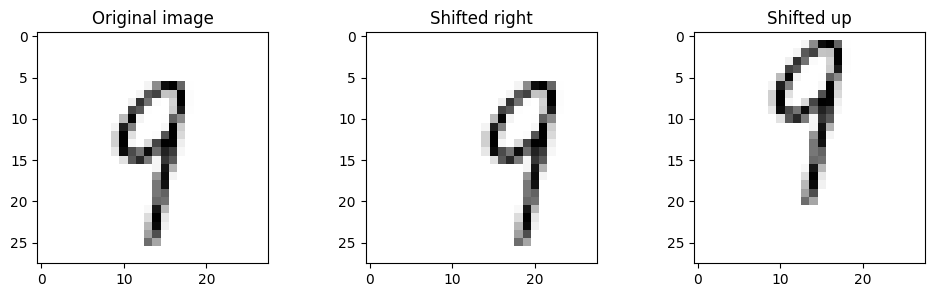

In [10]:
# Testing our new function
digit = X_train[900]
shifted_image_right = shift_image(digit, 0, 5)
shifted_image_up = shift_image(digit, -5, 0)

plt.figure(figsize=(12, 3))
plt.subplot(131)
plt.title("Original image")
plt.imshow(
    digit.reshape((28, 28)),
    interpolation='nearest',
    cmap='Greys'
)
plt.subplot(132)
plt.title("Shifted right")
plt.imshow(
    shifted_image_right.reshape((28, 28)),
    interpolation='nearest',
    cmap='Greys'
)
plt.subplot(133)
plt.title("Shifted up")
plt.imshow(
    shifted_image_up.reshape((28, 28)),
    interpolation='nearest',
    cmap='Greys'
)
plt.show()

In [12]:
X_train_augm = [image for image in X_train]
y_train_augm = [target for target in y_train]

for dy, dx in ((0, 1), (1, 0), (-1, 0), (0, -1)):
    for image, label in zip(X_train, y_train):
        X_train_augm.append(shift_image(image, dy, dx))
        y_train_augm.append(label)

X_train_augm = np.array(X_train_augm)
y_train_augm = np.array(y_train_augm)

In [14]:
# Now let's shuffle our new augmented training set
rng = np.random.default_rng(seed=42)
shuffle_idx = rng.permutation(len(X_train_augm))
X_train_augm = X_train_augm[shuffle_idx]
y_train_augm = y_train_augm[shuffle_idx]

In [16]:
# Creating teh best model with hyperparameters seen in exercise 1
knn_clf = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_clf.fit(X_train_augm, y_train_augm)
accuracy = knn_clf.score(X_test, y_test)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9763
